In [1]:
import pandas as pd
import sqlite3
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
DB_PATH = r"C:\Users\astha\Downloads\Machine Learning Project\data\inventory.db"
conn = sqlite3.connect(DB_PATH)
tables=pd.read_sql_query("Select name from sqlite_master where type='table'",conn)

In [3]:
tables

,name
0,purchases
1,purchase_prices
2,vendor_invoice
3,begin_inventory
4,end_inventory


In [4]:
for table in tables['name']:
    print("Table name:", table)
    df = pd.read_sql_query(f"SELECT * FROM {table} LIMIT 5;", conn)
    print(df, "\n")

Table name: purchases
           InventoryId  Store  Brand                   Description   Size  \
0    69_MOUNTMEND_8412     69   8412     Tequila Ocho Plata Fresno  750mL   
1     30_CULCHETH_5255     30   5255  TGI Fridays Ultimte Mudslide  1.75L   
2    34_PITMERDEN_5215     34   5215  TGI Fridays Long Island Iced  1.75L   
3  1_HARDERSFIELD_5255      1   5255  TGI Fridays Ultimte Mudslide  1.75L   
4    76_DONCASTER_2034     76   2034     Glendalough Double Barrel  750mL   

   VendorNumber                   VendorName  PONumber      PODate  \
0           105  ALTAMAR BRANDS LLC               8124  2023-12-21   
1          4466  AMERICAN VINTAGE BEVERAGE        8137  2023-12-22   
2          4466  AMERICAN VINTAGE BEVERAGE        8137  2023-12-22   
3          4466  AMERICAN VINTAGE BEVERAGE        8137  2023-12-22   
4           388  ATLANTIC IMPORTING COMPANY       8169  2023-12-24   

  ReceivingDate InvoiceDate     PayDate  PurchasePrice  Quantity  Dollars  \
0    2024-01-02  

In [5]:
vendor_df=pd.read_sql_query("select * from vendor_invoice",conn)
vendor_df.head()

,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


In [6]:
vendor_df[['Quantity','Freight','Dollars']].corr()

,Quantity,Freight,Dollars
Quantity,1.000000,0.946550,0.963831
Freight,0.946550,1.000000,0.985141
Dollars,0.963831,0.985141,1.000000


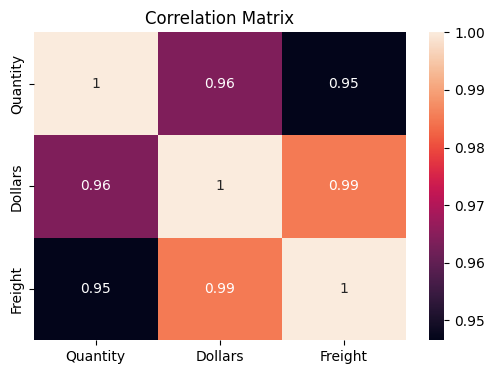

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.heatmap(
    vendor_df[['Quantity', 'Dollars', 'Freight']].corr(),
    annot=True
)
plt.title("Correlation Matrix")
plt.show()

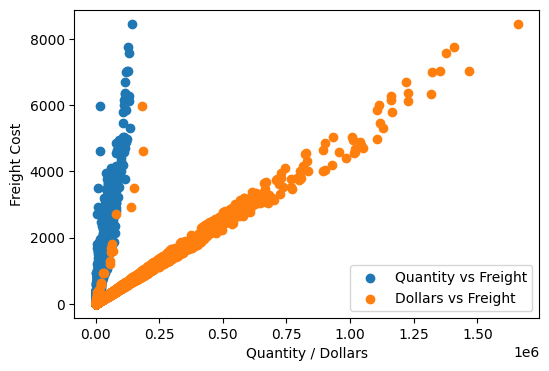

In [8]:
plt.figure(figsize=(6,4))
plt.scatter(vendor_df['Quantity'], vendor_df['Freight'], label='Quantity vs Freight')
plt.scatter(vendor_df['Dollars'], vendor_df['Freight'], label='Dollars vs Freight')
plt.xlabel('Quantity / Dollars')
plt.ylabel('Freight Cost')
plt.legend()
plt.show()

In [9]:
vendor_df['freight_per_unit'] = vendor_df['Freight'] / vendor_df['Quantity']


In [10]:
vendor_df

,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval,freight_per_unit
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None,0.578333
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None,0.571333
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None,0.922000
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None,0.290614
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None,0.221809
...,...,...,...,...,...,...,...,...,...,...,...
5538,9622,WEIN BAUER INC,2025-01-06,13626,2024-12-21,2025-02-10,90,1563.00,8.60,None,0.095556
5539,9625,WESTERN SPIRITS BEVERAGE CO,2025-01-10,13661,2024-12-23,2025-02-18,4617,37300.48,186.50,None,0.040394
5540,3664,WILLIAM GRANT & SONS INC,2025-01-02,13643,2024-12-22,2025-02-04,9848,202815.78,932.95,None,0.094735
5541,9815,WINE GROUP INC,2025-01-03,13602,2024-12-20,2025-02-08,24747,149007.56,819.54,None,0.033117


In [11]:
low_quantity = vendor_df['Quantity'].quantile(0.25)
high_quantity = vendor_df['Quantity'].quantile(0.75)

In [12]:
high_quantity

5100.5

In [13]:
low_quantity

83.0

In [15]:
vendor_df.loc[vendor_df['Quantity']<low_quantity,'freight_per_unit'].mean()

0.09489854253138316

In [16]:
vendor_df.loc[vendor_df['Quantity']>high_quantity,'freight_per_unit'].mean()

0.049077654690759046

In [17]:
X= vendor_df[['Quantity','Dollars']]
Y= vendor_df['Freight']

In [18]:
vendor_df.describe().round()

,VendorNumber,PONumber,Quantity,Dollars,Freight,freight_per_unit
count,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0
mean,20663.0,10889.0,6059.0,58073.0,296.0,0.0
std,34582.0,1601.0,14453.0,140234.0,714.0,0.0
min,2.0,8106.0,1.0,4.0,0.0,0.0
25%,3089.0,9504.0,83.0,968.0,5.0,0.0
50%,7240.0,10890.0,423.0,4765.0,25.0,0.0
75%,10754.0,12276.0,5100.0,44587.0,230.0,0.0
max,201359.0,13661.0,141660.0,1660436.0,8468.0,3.0


In [19]:
from sklearn.model_selection import train_test_split

In [20]:
X_train, X_test,y_train, y_test=train_test_split(X,Y, test_size=0.2, random_state= 42)

In [20]:
X_train

,Quantity,Dollars
2609,24,264.24
5527,36,342.48
5321,30,572.40
3805,10721,68821.14
1215,80495,604197.73
...,...,...
3772,161,2618.27
5191,6879,74386.98
5226,6,36.96
5390,80,644.00


In [21]:
X_test

,Quantity,Dollars
4564,48,352.95
1616,34773,225706.96
4861,70,634.11
230,104,987.34
2042,4314,31768.74
...,...,...
3388,36,242.16
1321,58,846.99
1322,33887,205379.19
3618,17998,242967.77


In [22]:

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [23]:
model1 = LinearRegression()
model1.fit(X_train, y_train)

model2 = DecisionTreeRegressor(random_state=42)
model2.fit(X_train, y_train)

model3 = RandomForestRegressor(random_state=42)
model3.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [24]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate_model(model, X_test, y_test, model_name):
    preds = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, preds)
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse) 
    r2 = r2_score(y_test, preds) * 100
    
    print(f"\n{model_name} Performance:")
    print("-" * 35)
    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R²   : {r2:.2f}%")
    
    return {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

In [25]:
evaluate_model(model1, X_test, y_test, 'Linear Regression')
evaluate_model(model2, X_test, y_test, 'Decision Tree Regression')
evaluate_model(model3, X_test, y_test, 'Random Forest Regression')


Linear Regression Performance:
-----------------------------------
MAE  : 24.4592
RMSE : 124.4288
R²   : 97.00%

Decision Tree Regression Performance:
-----------------------------------
MAE  : 33.8684
RMSE : 182.5008
R²   : 93.55%

Random Forest Regression Performance:
-----------------------------------
MAE  : 27.6458
RMSE : 138.6212
R²   : 96.28%


{'Model': 'Random Forest Regression',
 'MAE': 27.645808885229208,
 'RMSE': 138.62117343792318,
 'R2': 96.27905784240083}

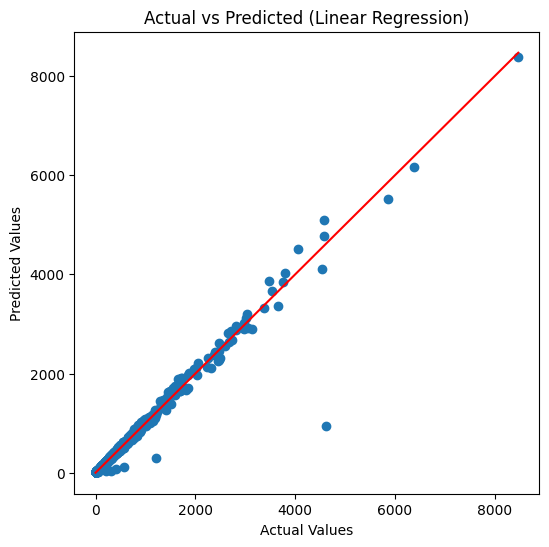

In [26]:
import matplotlib.pyplot as plt

y_pred = model1.predict(X_test)

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], color='red')

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted (Linear Regression)")
plt.show()

In [27]:
input_data = {
    "Dollars": [18500,9000],
}
df = pd.DataFrame(input_data)

In [28]:
input_data = {
    "Quantity": [1000, 500], # Added sample Quantity values
    "Dollars": [18500, 9000]
}

df = pd.DataFrame(input_data)

prediction = model1.predict(df[['Quantity', 'Dollars']]) # Updated to include 'Quantity'
print(prediction)

[100.06989033  51.53382746]
